In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'serif'

In [15]:

class Arrow3D(FancyArrowPatch):
    """3D arrow that projects correctly and renders on top of surfaces."""
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return min(zs)

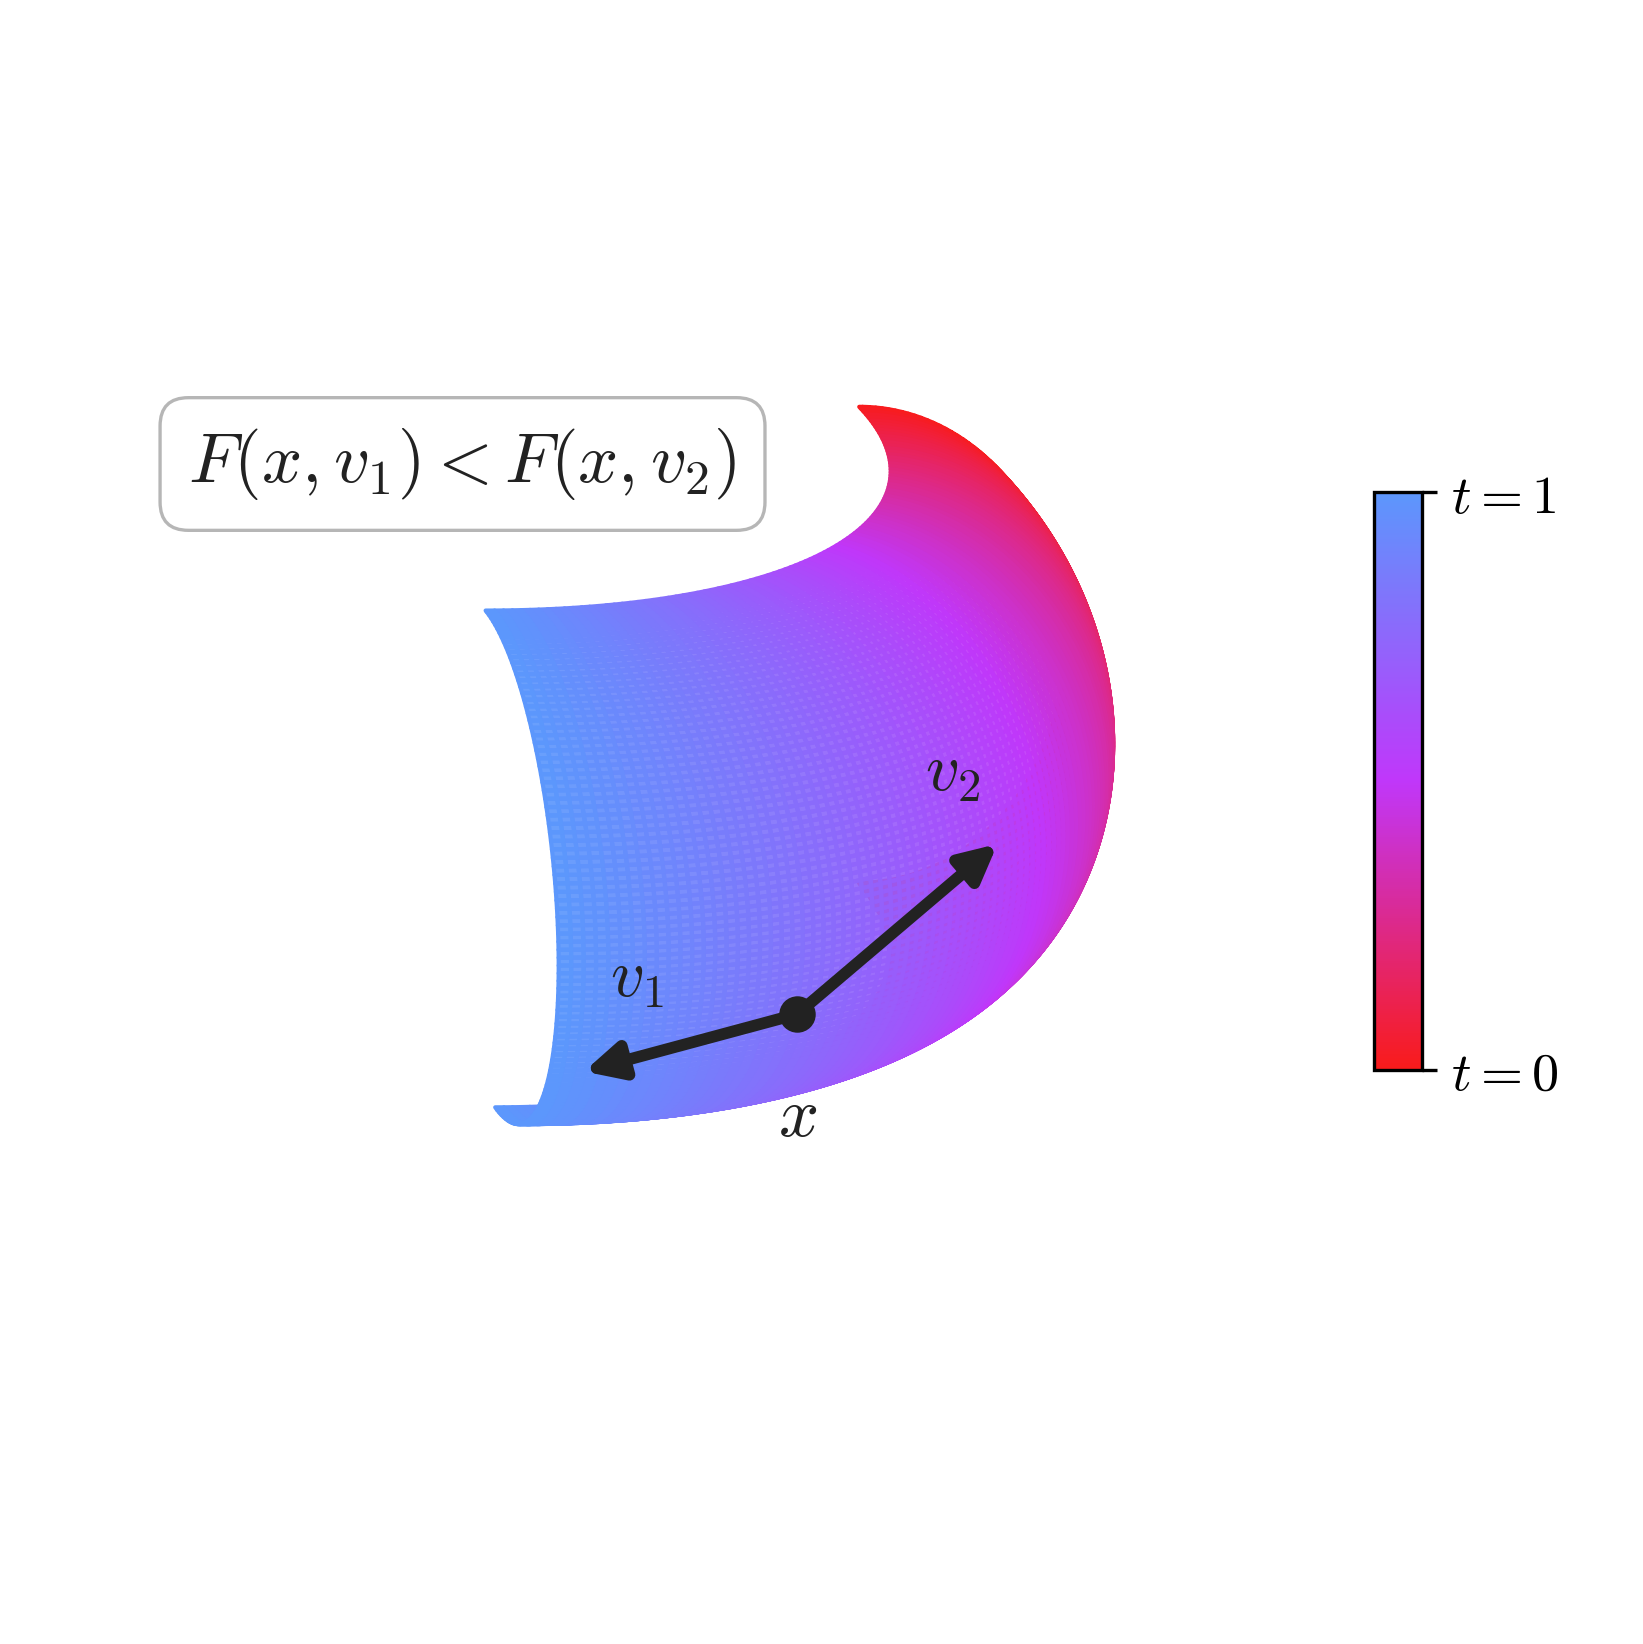

In [18]:

fig = plt.figure(figsize=(8, 5.5), dpi=300)
# Main 3D axes — centered with room for colorbar on right
ax = fig.add_axes([0.02, 0.02, 0.80, 0.96], projection='3d', computed_zorder=False)

# --- Torus patch (quarter) ---
R = 2.2   # major radius
r = 0.85  # minor radius

u = np.linspace(-0.5 * np.pi, 0.5 * np.pi, 200)   # tube angle (half tube)
v = np.linspace(-0.25 * np.pi, 0.25 * np.pi, 200)  # quarter ring
U, V = np.meshgrid(u, v)

X = (R + r * np.cos(U)) * np.cos(V)
Y = (R + r * np.cos(U)) * np.sin(V)
Z = r * np.sin(U)

# Strong red -> yellow gradient along the ring (V direction)
# V goes from negative (red, top-right in view) to positive (yellow, bottom-left)
color_param = 1.0 - (V - V.min()) / (V.max() - V.min())
cmap = LinearSegmentedColormap.from_list('red_yellow', [
    "#f91b1b",   # vivid red
    "#c037fa",   # deep orange
    "#5C97FC",   # rich golden yellow
])
colors = cmap(color_param)

surf = ax.plot_surface(
    X, Y, Z,
    facecolors=colors,
    rstride=2, cstride=2,
    antialiased=True,
    shade=False,
    lightsource=matplotlib.colors.LightSource(azdeg=315, altdeg=45),
    alpha=0.92,
    zorder=1,
)

# --- Point x ---
pu, pv = -0.35, -0.45  # lower front, rotated so t_v fans out in view plane
px = (R + r * np.cos(pu)) * np.cos(pv)
py = (R + r * np.cos(pu)) * np.sin(pv)
pz = r * np.sin(pu)

ax.scatter([px], [py], [pz], color='#222222', s=60, zorder=10, depthshade=False)
ax.text(px + 0.0, py + 0.0, pz - 0.42, r'$x$', fontsize=17, color='#222222',
        ha='center', zorder=10)

# --- Tangent vectors ---
t_u = np.array([
    -r * np.sin(pu) * np.cos(pv),
    -r * np.sin(pu) * np.sin(pv),
    r * np.cos(pu)
])
t_v = np.array([
    -(R + r * np.cos(pu)) * np.sin(pv),
    (R + r * np.cos(pu)) * np.cos(pv),
    0
])

# v1: toward yellow (lower Finsler cost) — along -v with upward tilt
v1_3d = -t_v - 0.35 * t_u
v1_3d = v1_3d / np.linalg.norm(v1_3d)

# v2: toward red (higher Finsler cost) — along +v with upward tilt (not exactly opposite v1)
v2_3d = t_v + 2.7 * t_u
v2_3d = v2_3d / np.linalg.norm(v2_3d)

p = np.array([px, py, pz])
v1_end = p + v1_3d
v2_end = p + v2_3d

# Draw arrows using FancyArrowPatch (always renders on top)
arrow_v1 = Arrow3D(
    [px, v1_end[0]], [py, v1_end[1]], [pz, v1_end[2]],
    mutation_scale=18, lw=2.8, arrowstyle='-|>',
    color='#222222', zorder=100
)
arrow_v2 = Arrow3D(
    [px, v2_end[0]], [py, v2_end[1]], [pz, v2_end[2]],
    mutation_scale=18, lw=2.8, arrowstyle='-|>',
    color='#222222', zorder=100
)
ax.add_artist(arrow_v1)
ax.add_artist(arrow_v2)

# Vector labels
ax.text(v1_end[0] + 0.12, v1_end[1] + 0.05, v1_end[2] + 0.28,
        r'$v_1$', fontsize=16, color='#222222', ha='left', zorder=100)
ax.text(v2_end[0] - 0.12, v2_end[1] + 0.05, v2_end[2] + 0.12,
        r'$v_2$', fontsize=16, color='#222222', ha='right', zorder=100)

# --- Equation ---
eq_text = r'$F (x, v_1) < F(x, v_2)$'
ax.text2D(0.10, 0.75, eq_text, transform=ax.transAxes,
          fontsize=17, ha='left', va='top',
          color='#222222',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                    edgecolor='#aaaaaa', alpha=0.85, linewidth=0.8))

# --- Clean axes ---
ax.set_xlim(0.5, 4.0)
ax.set_ylim(-2.5, 2.5)
ax.set_zlim(-1.2, 1.2)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')
ax.grid(False)
ax.set_axis_off()

ax.view_init(elev=25, azim=-55)

# (no tight_layout — using manual axes positioning)

# --- Colorbar legend ---
import matplotlib.colorbar as mcolorbar
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])

# Position: just right of the 3D axes, vertically centered
cbar_ax = fig.add_axes([0.65, 0.35, 0.02, 0.35])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_ticks([0, 1])
cbar.set_ticklabels([r'$t=0$', r'$t=1$'])
cbar.ax.tick_params(labelsize=13)
# t=0 (red) at bottom, t=1 (yellow) at top
# The cmap goes red(0) -> yellow(1), so default orientation is correct
# print("Done!")
# plt.show()
plt.savefig('manifold_finsler.png', dpi=300, bbox_inches='tight',
            pad_inches=0.1, transparent=False, facecolor='white')
